In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

In [2]:
df = pd.read_csv("../data/raw/aqi_data.csv")

In [3]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [5]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [6]:
df.describe(include = 'all')

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,29531,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000,24850
unique,26,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,Ahmedabad,2020-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,2009,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829
mean,NaN,NaN,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581,NaN
std,NaN,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585,NaN
min,NaN,NaN,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,NaN
25%,NaN,NaN,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000,NaN
50%,NaN,NaN,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000,NaN
75%,NaN,NaN,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000,NaN


In [7]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [8]:
df.columns

Index(['city', 'date', 'pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2',
       'o3', 'benzene', 'toluene', 'xylene', 'aqi', 'aqi_bucket'],
      dtype='object')

In [9]:
df['city'].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [10]:
df = df[df['city'].str.contains('Delhi', case=False, na=False)]

In [11]:
df

,city,date,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,aqi,aqi_bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12233,Delhi,2020-06-27,39.80,155.94,10.88,21.46,22.47,31.43,0.87,10.38,18.88,1.69,19.99,0.43,112.0,Moderate
12234,Delhi,2020-06-28,59.52,308.65,12.67,21.60,23.86,29.27,0.94,10.70,18.05,1.71,25.13,1.74,196.0,Moderate
12235,Delhi,2020-06-29,44.86,184.12,10.50,21.57,21.94,27.97,0.88,11.58,26.61,2.13,23.80,1.13,233.0,Poor
12236,Delhi,2020-06-30,39.80,91.98,5.99,17.96,15.44,28.48,0.84,10.51,37.29,1.57,16.37,0.49,114.0,Moderate


In [12]:
df.isnull().sum()

city            0
date            0
pm2.5           2
pm10           77
no              2
no2             2
nox             0
nh3             9
co              0
so2           110
o3             84
benzene         0
toluene         0
xylene        781
aqi            10
aqi_bucket     10
dtype: int64

In [13]:
# Xylene has ~61% missing values → it adds noise.
df = df.drop(columns=['xylene'])

In [14]:
numeric_cols = [
    'pm2.5', 'pm10', 'no', 'no2', 'nox',
    'nh3', 'co', 'so2', 'o3',
    'benzene', 'toluene', 'aqi'
]

df[numeric_cols] = df[numeric_cols].apply(
    lambda x: x.fillna(x.median())
)

In [15]:
df['aqi_bucket'] = df['aqi_bucket'].fillna(df['aqi_bucket'].mode()[0])

In [16]:
df.isnull().sum()

city          0
date          0
pm2.5         0
pm10          0
no            0
no2           0
nox           0
nh3           0
co            0
so2           0
o3            0
benzene       0
toluene       0
aqi           0
aqi_bucket    0
dtype: int64

In [17]:
df.to_csv("../data/processed/processed_aqi_data.csv", index=False)

### **Feature Engineering**

In [18]:
# Date–Time Features
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

In [19]:
df = df.drop(columns=['date'])
df = df.drop(columns=['city'])

In [20]:
# Pollutant Interaction Features
df['pm_ratio'] = df['pm2.5'] / (df['pm10'] + 1)
df['nox_total'] = df['no'] + df['no2']

In [21]:
df.to_csv("../data/finalist_aqi_data.csv", index=False)

In [33]:
df

,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,aqi,aqi_bucket,year,month,day,day_of_week,week_of_year,pm_ratio,nox_total
10229,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,472.0,Severe,2015,1,1,3,1,0.514335,105.55
10230,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,454.0,Severe,2015,1,2,4,1,0.688154,94.96
10231,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,143.0,Moderate,2015,1,3,5,1,0.655982,56.04
10232,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,319.0,Very Poor,2015,1,4,6,1,0.625268,61.92
10233,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,325.0,Very Poor,2015,1,5,0,2,0.665970,48.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12233,39.80,155.94,10.88,21.46,22.47,31.43,0.87,10.38,18.88,1.69,19.99,112.0,Moderate,2020,6,27,5,26,0.253600,32.34
12234,59.52,308.65,12.67,21.60,23.86,29.27,0.94,10.70,18.05,1.71,25.13,196.0,Moderate,2020,6,28,6,26,0.192217,34.27
12235,44.86,184.12,10.50,21.57,21.94,27.97,0.88,11.58,26.61,2.13,23.80,233.0,Poor,2020,6,29,0,27,0.242329,32.07
12236,39.80,91.98,5.99,17.96,15.44,28.48,0.84,10.51,37.29,1.57,16.37,114.0,Moderate,2020,6,30,1,27,0.428049,23.95


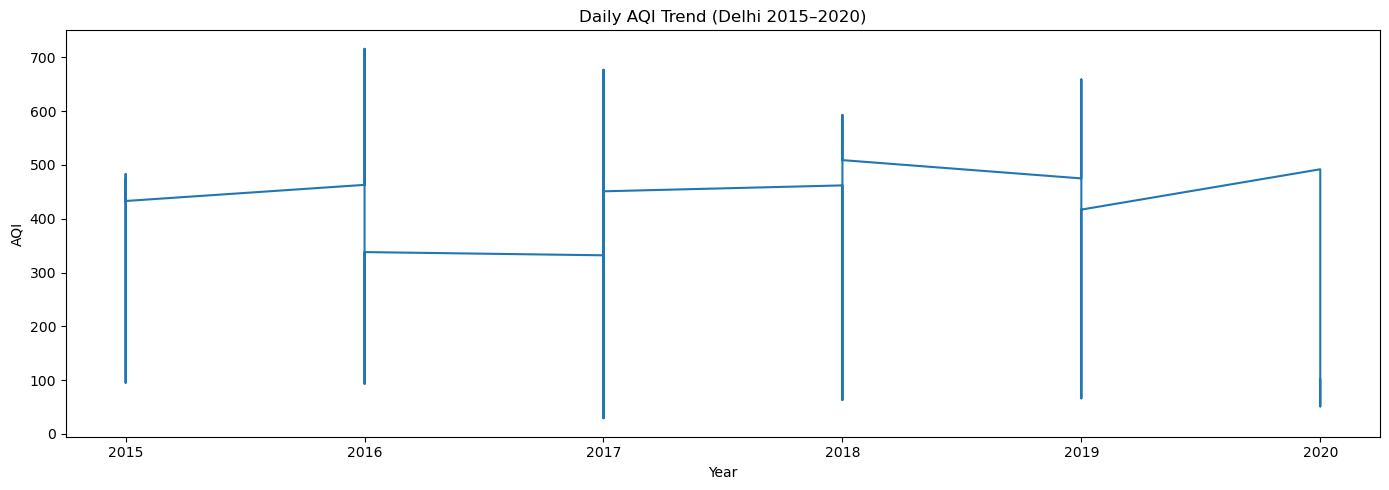

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(df['year'], df['aqi'])
plt.xlabel("Year")
plt.ylabel("AQI")
plt.title("Daily AQI Trend (Delhi 2015–2020)")
plt.tight_layout()
plt.show()

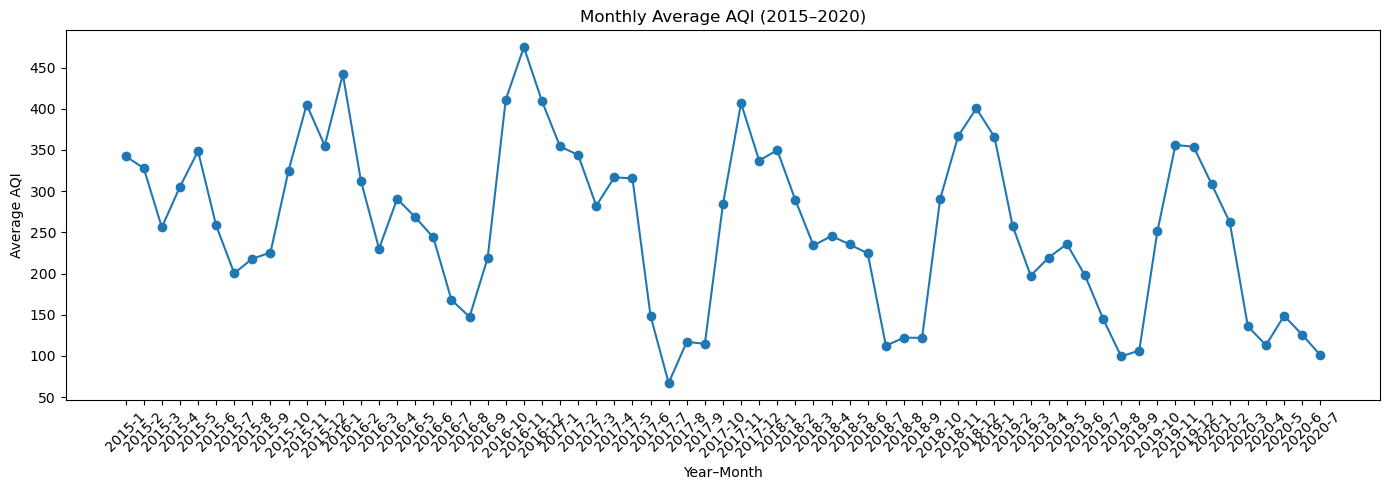

In [23]:
# Monthly average AQI
monthly_avg = df.groupby(['year', 'month'])['aqi'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg.index, monthly_avg['aqi'], marker='o')
plt.title("Monthly Average AQI (2015–2020)")
plt.xlabel("Year–Month")
plt.ylabel("Average AQI")

# Create readable Year-Month labels
labels = monthly_avg['year'].astype(str) + "-" + monthly_avg['month'].astype(str)
plt.xticks(monthly_avg.index, labels, rotation=45)

plt.tight_layout()
plt.show()

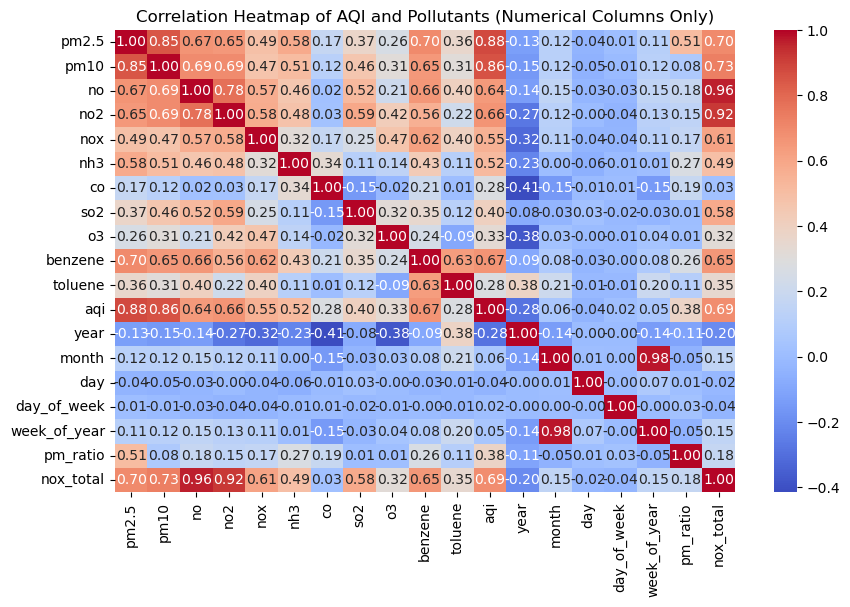

In [24]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of AQI and Pollutants (Numerical Columns Only)")
plt.show()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2009 entries, 10229 to 12237
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pm2.5         2009 non-null   float64
 1   pm10          2009 non-null   float64
 2   no            2009 non-null   float64
 3   no2           2009 non-null   float64
 4   nox           2009 non-null   float64
 5   nh3           2009 non-null   float64
 6   co            2009 non-null   float64
 7   so2           2009 non-null   float64
 8   o3            2009 non-null   float64
 9   benzene       2009 non-null   float64
 10  toluene       2009 non-null   float64
 11  aqi           2009 non-null   float64
 12  aqi_bucket    2009 non-null   object 
 13  year          2009 non-null   int32  
 14  month         2009 non-null   int32  
 15  day           2009 non-null   int32  
 16  day_of_week   2009 non-null   int32  
 17  week_of_year  2009 non-null   int32  
 18  pm_ratio      2009 non-null 

### **80–20 Train-Test Split**

In [26]:
X = df[['pm2.5', 'pm10', 'no', 'no2', 'nox',
        'nh3', 'co', 'so2', 'o3',
        'benzene', 'toluene',
        'pm_ratio', 'nox_total',
        'year', 'month', 'day',
        'day_of_week', 'week_of_year']]

y = df['aqi']

# 80% training size
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

### **Models**

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "SVM": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
}

results = {}
trained_models = {}

### **Train & Evaluate Models**

In [28]:
for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    }

    trained_models[name] = model

Training Linear Regression...
Training Random Forest...
Training SVM...
Training XGBoost...


In [29]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2", ascending=False)

print("\nModel Comparison Results:")
print(results_df.round(4))


Model Comparison Results:
                       R2      RMSE       MAE
Random Forest      0.9466   26.2055   19.5772
XGBoost            0.9403   27.7051   20.0514
Linear Regression  0.9156   32.9429   22.7282
SVM               -0.1935  123.9070  109.8383


In [30]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"\nBest Model Selected: {best_model_name}")


Best Model Selected: Random Forest


In [31]:
joblib.dump(best_model, "best_aqi_model.pkl")

print("Best model saved as best_aqi_model.pkl")

Best model saved as best_aqi_model.pkl
